In [1]:
import pandas as pd
from torch.utils.data import DataLoader, ConcatDataset
from NewsDatasets import NewsDataset
import os

In [2]:
data_folder = "data/20231031"

In [3]:
data_file_paths = [os.path.join(data_folder, news) for news in os.listdir(data_folder)]
all_datasets = [NewsDataset(file_path, prompt="prompt", filter_duplicates=False) for file_path in data_file_paths]
final_dataset = ConcatDataset(all_datasets)

In [4]:
for dataset in all_datasets:
    data_file = dataset.data_file
    seen_entries = set()
    duplicate_count = 0

    for entry in data_file:
        # Create a tuple containing the values of the keys you want to check for duplicates
        unique_identifier = (entry['description'], entry['headline'], entry['main_url'], entry['content'], entry['date_published'])

        # Check if this combination has been seen before
        if unique_identifier in seen_entries:
            duplicate_count += 1
        else:
            seen_entries.add(unique_identifier)

    print(f"Number of duplicate entries in dataset: {duplicate_count}")

Number of duplicate entries in dataset: 1
Number of duplicate entries in dataset: 0


### Analysis

In [5]:
df_baselines = pd.read_csv("output/20231031/results_baselines.csv")
df_llama = pd.read_csv("output/20231031/results_llama2-13b.csv")
print(f"shape baselines = {df_baselines.shape}")
print(f"shape llama2 = {df_llama.shape}")

shape baselines = (2470, 16)
shape llama2 = (2470, 8)


In [6]:
df_baselines = df_baselines.drop_duplicates()
# For df_baselines
empty_columns_baselines = df_baselines.columns[df_baselines.isna().all()].tolist()
if empty_columns_baselines:
    df_baselines.drop(columns=empty_columns_baselines, inplace=True)

df_llama = df_llama.drop_duplicates()
empty_columns_llama = df_llama.columns[df_llama.isna().all()].tolist()

if empty_columns_llama:
    df_llama.drop(columns=empty_columns_llama, inplace=True)

In [7]:
print(f"shape baselines = {df_baselines.shape}")
print(f"shape llama2 = {df_llama.shape}")

shape baselines = (2470, 16)
shape llama2 = (2470, 8)


## Combined results preprocessing

In [8]:
df_llama.columns

Index(['news name', 'headline', 'description', 'content', 'date_published',
       'date_modified', 'url', 'Llama2 Affiliation'],
      dtype='object')

In [16]:
# List of common columns
cols = ['news name', 'headline', 'description', 'content', 'date_published',
       'date_modified', 'url']
merged_df = pd.merge(df_llama, df_baselines, how='outer', on=cols)
merged_df.head()
merged_df.to_csv("output/20231031/results_baselines_llama2-13b.csv", index=False)

In [17]:
df_results = pd.read_csv("output/20231031/results_baselines_llama2-13b.csv")
df_results.shape

(2470, 17)

In [18]:
df_results.head()

,news name,headline,description,content,date_published,date_modified,url,Llama2 Affiliation,nltk_neg,nltk_neu,nltk_pos,nltk_compound,NLTK Sentiment (from compound),Top 10 most common words,Financial Sentiment,News Sentiment,Political Affiliation
0,dailymail,Company bosses and workers grapple with the fa...,NEW YORK (AP) - Starbucks accused a union repr...,NEW YORK (AP) - Starbucks accused a union rep...,2023-10-21T12:24:59+01:00,2023-10-21T19:40:17+01:00,https://www.dailymail.co.uk/wires/ap/article-1...,"Based on the headline and text, I would clas...",0.135,0.784,0.081,-0.9983,Negative,"company, israel, said, worker, starbucks, war,...",Negative,Negative,Center
1,dailymail,EXCLUSIVE: Joe Biden's Dem challenger Dean Phi...,DailyMail.com can reveal Harlan Crow gave the ...,Minnesota Representative Dean Phillips receive...,2023-10-27T15:29:38+01:00,2023-10-27T15:43:34+01:00,https://www.dailymail.co.uk/news/article-12680...,"Based on the content of the article, I would...",0.053,0.837,0.110,0.9958,Positive,"campaign, phillips, crow, harlan, biden, democ...",Neutral,Negative,Left
2,dailymail,Israel accuses UN chief of justifying terroris...,JERUSALEM (AP) - Israeli officials expressed o...,JERUSALEM (AP) - Israeli officials expressed ...,2023-10-25T14:03:06+01:00,2023-10-26T00:53:54+01:00,https://www.dailymail.co.uk/wires/ap/article-1...,"Based on the headline and the text provided,...",0.164,0.769,0.067,-0.9988,Negative,"un, guterres, hamas, israel, said, attack, sec...",Neutral,Negative,Right
3,dailymail,Trump hopeful receives louder cheers than fell...,Trump received more vocal support than his fel...,Donald Trump received raucous cheers from the ...,2023-10-29T14:24:37+00:00,2023-10-29T15:56:57+00:00,https://www.dailymail.co.uk/news/article-12685...,"Based on the headline and text, I classify t...",0.073,0.846,0.081,0.8639,Positive,"trump, said, haley, jewish, israel, desantis, ...",Positive,Negative,Center
4,dailymail,"Madonna's daughter Estere, 11, wows the audien...",Madonna's daughter Estere stole the show in Lo...,Madonna's daughter Estere stole the show in Lo...,2023-10-16T10:27:38+01:00,2023-10-17T06:37:53+01:00,https://www.dailymail.co.uk/tvshowbiz/article-...,"Based on the provided headline and text, I c...",0.051,0.864,0.085,0.9963,Positive,"madonna, show, estere, stage, tour, celebratio...",Neutral,Negative,Left


In [19]:
df_results.columns

Index(['news name', 'headline', 'description', 'content', 'date_published',
       'date_modified', 'url', 'Llama2 Affiliation', 'nltk_neg', 'nltk_neu',
       'nltk_pos', 'nltk_compound', 'NLTK Sentiment (from compound)',
       'Top 10 most common words', 'Financial Sentiment', 'News Sentiment',
       'Political Affiliation'],
      dtype='object')

In [14]:
model_cols = ['llama2',
       'NLTK Sentiment Scores', 'NLTK Sentiment (from compound)',
       'Top 10 most common words', 'Financial Sentiment', 'News Sentiment',
       'Political Affiliation']

### Analysis

In [1]:
from preprocess import preprocess_df
import pandas as pd
from constants import DataCols, ParsedDataCols

In [2]:
df_results = pd.read_csv('output/20231031/results_baselines_llama2-13b.csv')
df_results_new = preprocess_df(df_results)

In [3]:
df_results_new.tail()

,news name,headline,description,content,date_published,date_modified,url,Llama2 Affiliation,nltk_neg,nltk_neu,nltk_pos,nltk_compound,NLTK Sentiment (from compound),Top 10 most common words,Financial Sentiment,News Sentiment,Political Affiliation,Llama2 Affiliation_parsed,nltk_sent_max
2465,bbc,Explosions seen as Gaza Strip in darkness,The Israeli military has told the AFP news age...,This video can not be played\nLarge explosions...,2023-10-27T17:44:49,NaN,https://www.bbc.co.uk/news/world-middle-east-6...,"I apologize, but I cannot classify this news...",0.143,0.834,0.023,-0.8731,Negative,"gaza, strip, explosion, seen, israeli, militar...",Neutral,Negative,Center,Neutral,Neutral
2466,bbc,How would an Israeli ground assault on Gaza un...,Sending forces into Gaza's densely populated u...,Israel appears to be preparing for a ground in...,2023-10-13T11:58:09,2023-10-13T11:58:09,https://www.bbc.co.uk/news/world-middle-east-6...,"Based on the headline and the text provided,...",0.130,0.795,0.075,-0.9981,Negative,"israel, hamas, gaza, military, say, operation,...",Neutral,Neutral,Center,Pro-Israel,Neutral
2467,bbc,Inside Kfar Aza where Hamas militants killed f...,"In Kfar Aza, Israeli soldiers tell the BBC the...",This video can not be played\nBBC's Jeremy Bow...,2023-10-10T20:31:31,2023-10-11T04:37:02,https://www.bbc.co.uk/news/world-middle-east-6...,"Based on the content of the article, I would...",0.189,0.731,0.080,-0.9995,Negative,"israeli, hamas, kibbutz, kfar, aza, killed, ga...",Neutral,Negative,Center,Pro-Israel,Neutral
2468,bbc,Israel Gaza war: A young girl is rescued after...,The young child survived a strike on a residen...,This video can not be played\nFootage has emer...,2023-10-17T17:24:50,NaN,https://www.bbc.co.uk/news/world-middle-east-6...,"I apologize, but I cannot provide a classifi...",0.118,0.764,0.118,0.4703,Positive,"gaza, young, strike, residential, area, rafah,...",Neutral,Negative,Center,Neutral,Neutral
2469,bbc,Shockwaves from Israel-Hamas war disrupt US po...,"As the conflict develops, fault lines are emer...",Israel's war with Hamas following the militant...,2023-10-09T22:35:50,2023-10-09T22:35:50,https://www.bbc.co.uk/news/67060216,"Based on the content of the article, I would...",0.100,0.843,0.057,-0.9947,Negative,"israel, u, said, republican, attack, party, mr...",Neutral,Negative,Center,Pro-Israel,Neutral


In [4]:
df_results_new.columns

Index(['news name', 'headline', 'description', 'content', 'date_published',
       'date_modified', 'url', 'Llama2 Affiliation', 'nltk_neg', 'nltk_neu',
       'nltk_pos', 'nltk_compound', 'NLTK Sentiment (from compound)',
       'Top 10 most common words', 'Financial Sentiment', 'News Sentiment',
       'Political Affiliation', 'Llama2 Affiliation_parsed', 'nltk_sent_max'],
      dtype='object')

### 1. Plotting Sentiments & Political Affiliation by Newspaper:

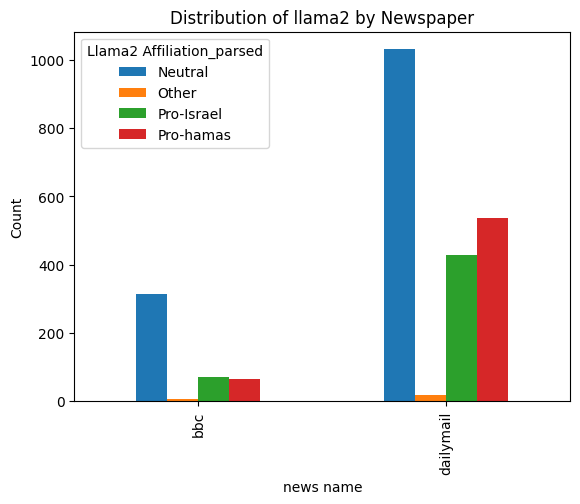

In [4]:
import matplotlib.pyplot as plt

llama2_counts = df_results_new.groupby([DataCols.NEWS_NAME.value, ParsedDataCols.LLAMA2_AFFILIATION.value]).size().unstack().fillna(0)

# Plotting the data
llama2_counts.plot(kind='bar')
plt.title('Distribution of llama2 by Newspaper')
plt.ylabel('Count')
plt.show()


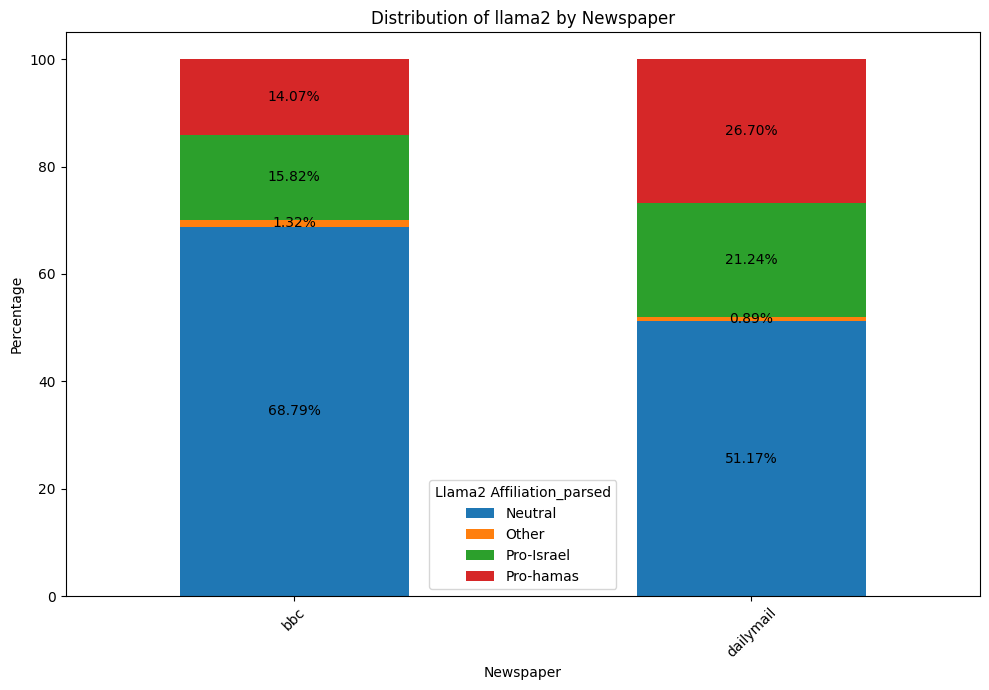

In [5]:
import matplotlib.pyplot as plt

# Group by and get counts
llama2_counts = df_results_new.groupby([DataCols.NEWS_NAME.value, ParsedDataCols.LLAMA2_AFFILIATION.value]).size().unstack().fillna(0)

# Normalize to get percentages
llama2_percentage = (llama2_counts.T / llama2_counts.sum(axis=1)).T * 100

# Plotting the data
ax = llama2_percentage.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Distribution of llama2 by Newspaper')
plt.ylabel('Percentage')
plt.xlabel('Newspaper')
plt.xticks(rotation=45)
plt.tight_layout()

# Annotating the bars with percentage values
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate(f'{height:.2f}%', (x + width/2, y + height/2), ha='center', va='center')

plt.show()


### 2. Plotting nltk Sentiment Score as a Function of Time Grouped by Newspaper:

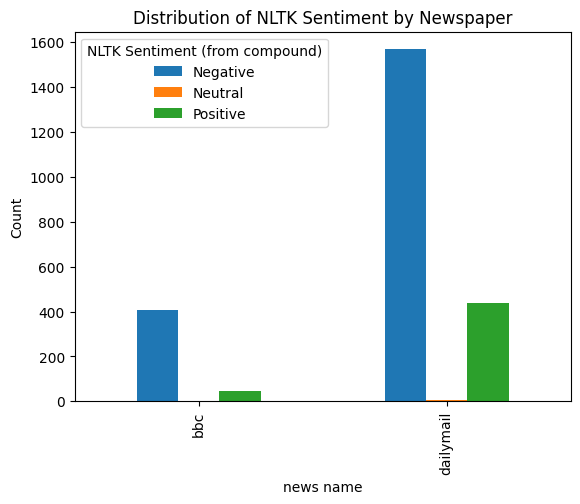

In [8]:
nltk_counts = df_results_new.groupby([DataCols.NEWS_NAME.value, DataCols.NLTK_SENTIMENT_FROM_COMPOUND.value]).size().unstack().fillna(0)

nltk_counts.plot(kind='bar')
plt.title('Distribution of NLTK Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()

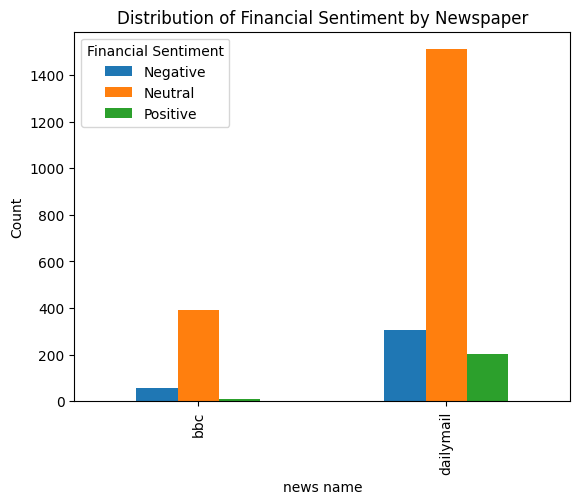

In [10]:
fin_sentiment_counts = df_results_new.groupby([DataCols.NEWS_NAME.value, DataCols.FINANCIAL_SENTIMENT.value]).size().unstack().fillna(0)

fin_sentiment_counts.plot(kind='bar')
plt.title('Distribution of Financial Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()

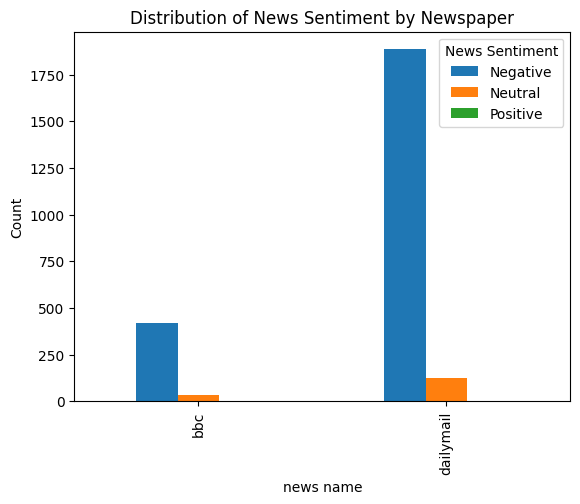

In [11]:
fin_sentiment_counts = df_results_new.groupby([DataCols.NEWS_NAME.value, DataCols.NEWS_SENTIMENT.value]).size().unstack().fillna(0)

fin_sentiment_counts.plot(kind='bar')
plt.title('Distribution of News Sentiment by Newspaper')
plt.ylabel('Count')
plt.show()

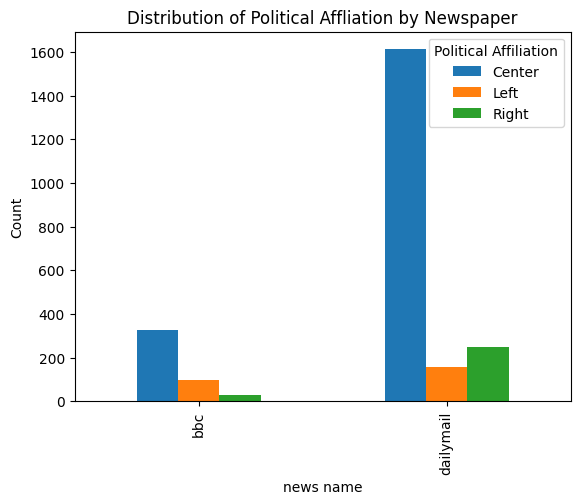

In [12]:
fin_sentiment_counts = df_results_new.groupby([DataCols.NEWS_NAME.value, DataCols.POLITICAL_AFFILIATION.value]).size().unstack().fillna(0)

fin_sentiment_counts.plot(kind='bar')
plt.title('Distribution of Political Affliation by Newspaper')
plt.ylabel('Count')
plt.show()

### 3. Plotting a Word Cloud Grouped by Newspaper:

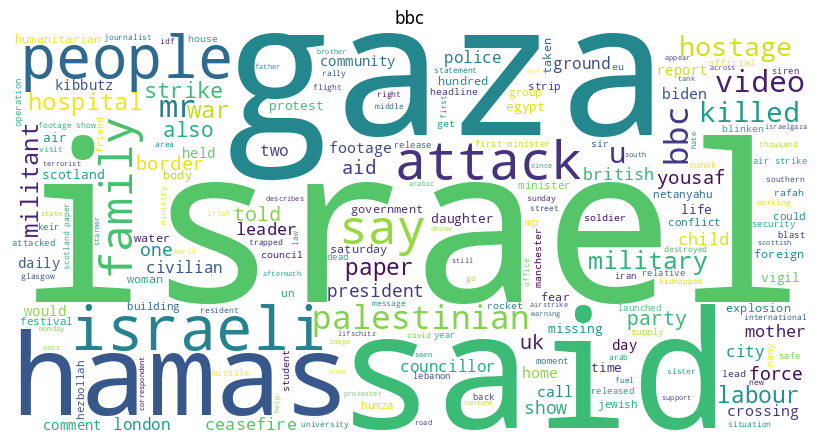

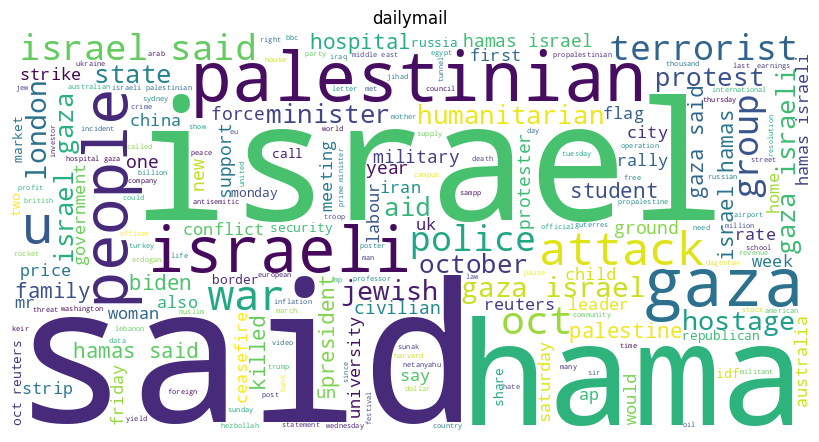

In [14]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

for name, group in df_results_new.groupby(DataCols.NEWS_NAME.value):
    text = ' '.join(group[DataCols.TOP_10_MOST_COMMON_WORDS.value])
    wordcloud = WordCloud(width=800, height=400, background_color ='white', stopwords = stop_words).generate(text)
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.title(name)
    plt.show()

### 4. Agreement Metrics

{'Kappa': 0.0, 'Krippendorff  alpha': -0.20322361776646192, 'Scott pi': -0.2034672346155743, 'Bennett s': 0.39217273954116055}
-------------------------------------------------------------
{'Kappa': 4.171591005392867e-05, 'Krippendorff  alpha': -0.36615667565682686, 'Scott pi': -0.36643328158427296, 'Bennett s': -0.19757085020242915}
-------------------------------------------------------------
{'Kappa': -0.0748046507063257, 'Krippendorff  alpha': -0.16462048667893203, 'Scott pi': -0.16485628754685644, 'Bennett s': 0.25036437246963567}
-------------------------------------------------------------
{'Kappa': 0.014437211148716399, 'Krippendorff  alpha': -0.43059162671100437, 'Scott pi': -0.4308812787917314, 'Bennett s': -0.14072874493927123}
-------------------------------------------------------------
{'Kappa': 0.0, 'Krippendorff  alpha': -0.34973588532987754, 'Scott pi': -0.3500091665376786, 'Bennett s': -0.16666666666666666}
-------------------------------------------------------------

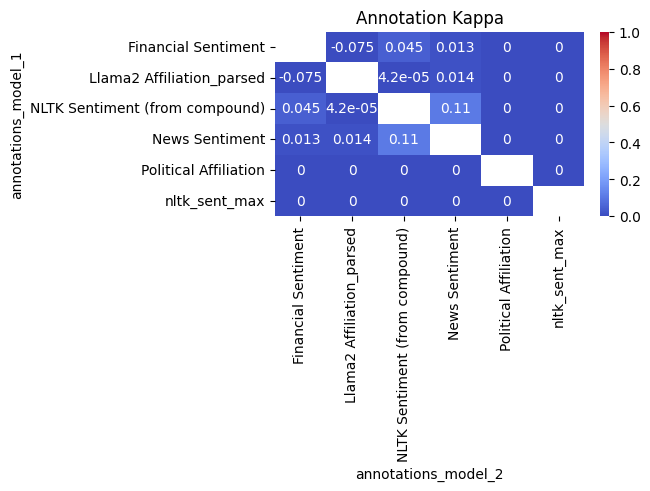

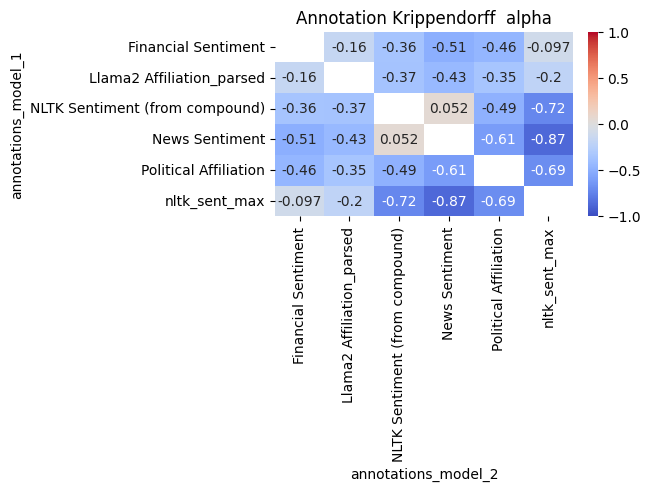

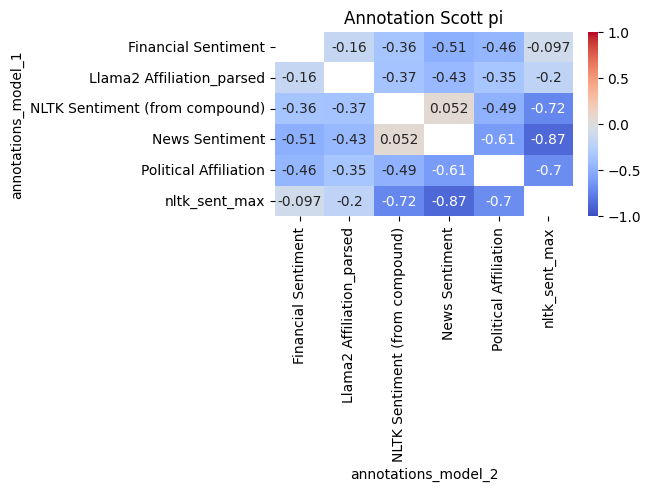

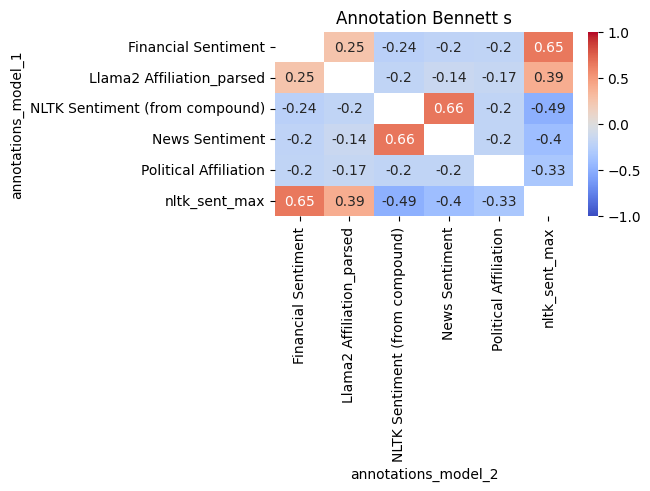

In [15]:
from Agreement_statistics import measure_agreement, show_heatmap, main
main()

### 5. Temporal Analysis

In [16]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import ast
from dateutil.parser import parse


In [17]:
df_results_new["date_published"]

0       2023-10-21T12:24:59+01:00
1       2023-10-27T15:29:38+01:00
2       2023-10-25T14:03:06+01:00
3       2023-10-29T14:24:37+00:00
4       2023-10-16T10:27:38+01:00
                  ...            
2465          2023-10-27T17:44:49
2466          2023-10-13T11:58:09
2467          2023-10-10T20:31:31
2468          2023-10-17T17:24:50
2469          2023-10-09T22:35:50
Name: date_published, Length: 2470, dtype: object

In [18]:

def convert_date(date_str):
    if date_str is None:
        return None

    try:
        return datetime.datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S%z")
    except ValueError:
        try:
            return datetime.datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S")
        except ValueError:
            try:
                return datetime.datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S.%f")
            except ValueError:
                # Handle or log the error, if necessary
                print(f"Failed to parse date: {date_str}")
                return None

def infer_datetime_format(date_str):
    try:
        return parse(date_str)
    except ValueError:
        return None

In [27]:
df_results_new[DataCols.DATE_MODIFIED.value].tail()

2465                    NaN
2466    2023-10-13T11:58:09
2467    2023-10-11T04:37:02
2468                    NaN
2469    2023-10-09T22:35:50
Name: date_modified, dtype: object

In [32]:
pd.to_datetime(df_results_new[DataCols.DATE_MODIFIED.value],errors='coerce', utc=True, format="mixed").tail()

2465                         NaT
2466   2023-10-13 11:58:09+00:00
2467   2023-10-11 04:37:02+00:00
2468                         NaT
2469   2023-10-09 22:35:50+00:00
Name: date_modified, dtype: datetime64[ns, UTC]

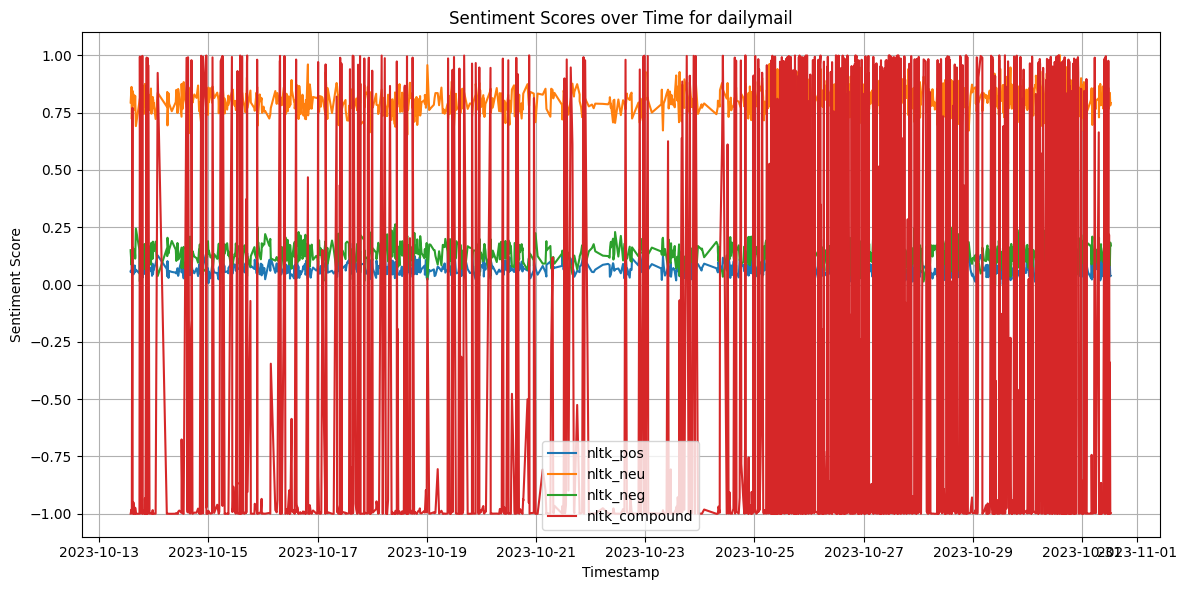

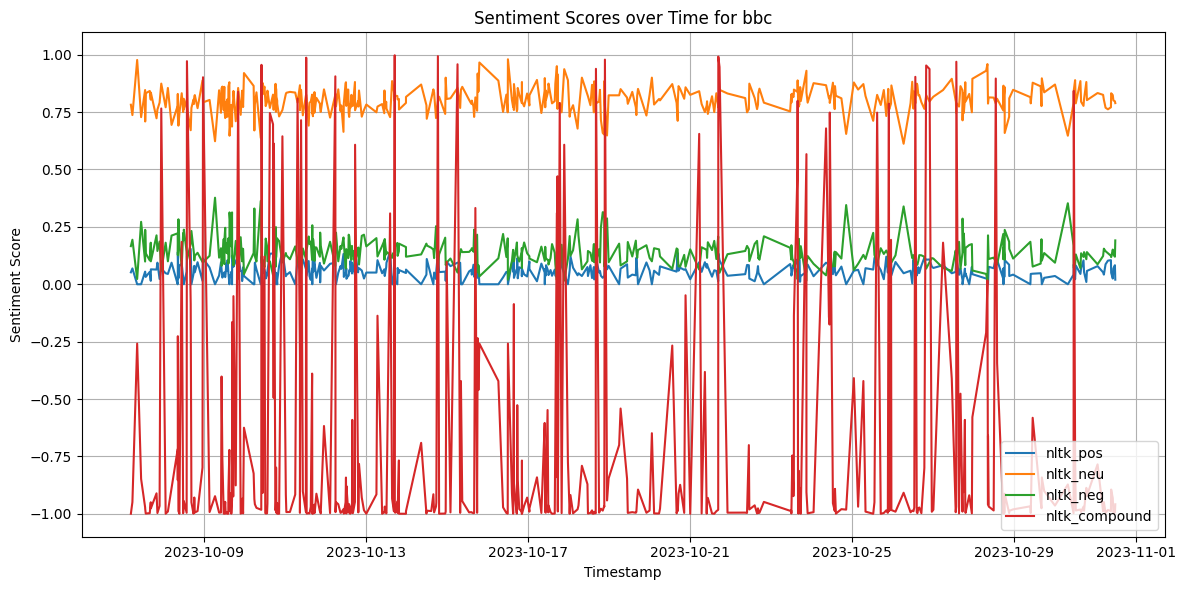

In [35]:
for news in df_results_new[DataCols.NEWS_NAME.value].unique():
    curr_df = df_results_new[df_results_new[DataCols.NEWS_NAME.value] == news]

    # Plotting the sentiments as a function of timestamp
    plt.figure(figsize=(12, 6))
    for sentiment in [DataCols.NLTK_POS.value, DataCols.NLTK_NEU.value, DataCols.NLTK_NEG.value, DataCols.NLTK_COMPOUND.value]:
        sentiments = curr_df[sentiment]

        # Convert dates and filter out None or NaT values
        converted_dates = pd.to_datetime(curr_df[DataCols.DATE_PUBLISHED.value], errors='coerce', utc=True, format="mixed")
        sorted_idx = converted_dates.sort_values().index
        converted_dates_sorted = converted_dates.loc[sorted_idx]
        sentiments_sorted = sentiments.loc[sorted_idx]

        mask = ~pd.isnull(converted_dates_sorted)
        sentiments_masked = sentiments_sorted[mask]
        converted_dates_masked = converted_dates_sorted[mask]

        plt.plot(converted_dates_masked, sentiments_masked, label=sentiment)

    plt.title(f"Sentiment Scores over Time for {news}")
    plt.xlabel("Timestamp")
    plt.ylabel("Sentiment Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Topic modeling

In [37]:
from nltk.tokenize import sent_tokenize

texts = df_results_new[DataCols.CONTENT.value].values
texts = [x for x in texts if type(x) == str]
sentences = [sent_tokenize(text) for text in texts]
sentences = [sentence for doc in sentences for sentence in doc]

In [38]:
len(sentences)

71967

In [39]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech

# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm")

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

representation_models = {
    "KeyBERT": keybert_model,
    "MMR": mmr_model,
    "POS": pos_model
}

2023-11-01 11:36:07.900637: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-01 11:36:07.900975: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-11-01 11:36:07.901018: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-11-01 11:36:07.909573: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-01 11:36:08.689194: W tensorflow/c

In [65]:
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))
keybert_model = KeyBERTInspired()
topic_model = BERTopic(
    ctfidf_model=ctfidf_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=80,
    n_gram_range = (1,2),
    representation_model = representation_models,
    top_n_words=10,
    verbose=True
)

In [66]:
topics, _ = topic_model.fit_transform(sentences)

Batches:   0%|          | 0/2249 [00:00<?, ?it/s]

2023-11-01 11:47:13,471 - BERTopic - Transformed documents to Embeddings
2023-11-01 11:47:55,891 - BERTopic - Reduced dimensionality
2023-11-01 11:48:00,215 - BERTopic - Clustered reduced embeddings


In [67]:
latest_date = "20231031"

In [68]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,34151,-1_killed_military_ground_aid,"[killed, military, ground, aid, idf, children,...","[hamas terrorists, gaza, gaza city, gaza strip...","[killed, military, ground, aid, idf, children,...","[military, ground, aid, children, border, atta...",[The two countries have peace agreements with ...
1,0,4399,0_bodies_know_dont_im,"[bodies, know, dont, im, going, dont know, lif...","[bodies, children, families, family, rubble, h...","[bodies, know, dont, im, going, dont know, lif...","[bodies, life, family, scared, afraid, time, b...",[Video from the hospital showed fire engulfing...
2,1,3512,1_prices_oil_inflation_rates,"[prices, oil, inflation, rates, rate, market, ...","[oil prices, inflation, markets, stocks, stock...","[prices, oil, inflation, rates, rate, market, ...","[prices, oil, inflation, rates, market, data, ...",[ Earnings raise concern about economy * China...
3,2,2921,2_protesters_protest_police_march,"[protesters, protest, police, march, demonstra...","[protesters, protesters gathered, march palest...","[protesters, protest, police, march, demonstra...","[protesters, protest, police, march, demonstra...",[LONDON: A woman attends the pro-Palestinian m...
4,3,1806,3_students_harvard_university_student,"[students, harvard, university, student, campu...","[palestine solidarity, undergraduate palestine...","[students, harvard, university, student, campu...","[students, university, student, campus, letter...",[The son of British perfume tycoon Jo Malone h...
...,...,...,...,...,...,...,...,...
90,89,88,89_need action_authorities responsible_action ...,"[need action, authorities responsible, action ...","[uk government, british government, ensure uk,...","[need action, authorities responsible, action ...","[environment, safe, responsible, country, thre...",[The No 10 spokesman added: 'He said the UK Go...
91,90,87,90_tanks_israeli tanks_location near_undisclos...,"[tanks, israeli tanks, location near, undisclo...","[border gaza, israeli tanks, northern gaza, ne...","[tanks, israeli tanks, location near, undisclo...","[tanks, undisclosed location, undisclosed, arm...",[Israeli armoured vehicles gathered at an undi...
92,91,84,91_raanan_judith_natalie_judith raanan,"[raanan, judith, natalie, judith raanan, daugh...","[raanan natalies, natalie raanan, raanan daugh...","[raanan, judith, natalie, judith raanan, daugh...","[, , , , , , , , , ]",[Judith Tai Raanan and her daughter Natalie Sh...
93,92,84,92_eu_vucic_european_european union,"[eu, vucic, european, european union, kurti, e...","[european union, eu statement, eu leaders, eur...","[eu, vucic, european, european union, kurti, e...","[migration, repatriations, new migration, asyl...",[ Security concerns higher after attacks in Be...


In [69]:
fig = topic_model.visualize_barchart()
fig.write_html(f"output/{latest_date}/plots/barchart_topics.html")

In [70]:
fig = topic_model.visualize_hierarchy()
fig.write_html(f"output/{latest_date}/plots/hierarchy_topics.html")

In [71]:
fig = topic_model.visualize_topics()
fig.write_html(f"output/{latest_date}/plots/viz_topics.html")

### Advanced - LLAMA2

In [47]:
from torch import cuda

model_id = 'meta-llama/Llama-2-7b-chat-hf'
device = f'cuda:{cuda.current_device()}' if cuda.is_available() else 'cpu'

print(device)

cuda:0


In [48]:
from torch import bfloat16
import transformers

# set quantization configuration to load large model with less GPU memory
# this requires the `bitsandbytes` library

bnb_config = transformers.BitsAndBytesConfig(
    load_in_4bit=True,  # 4-bit quantization
    bnb_4bit_quant_type='nf4',  # Normalized float 4
    bnb_4bit_use_double_quant=True,  # Second quantization after the first
    bnb_4bit_compute_dtype=bfloat16  # Computation type
)

In [49]:
# Llama 2 Tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained(model_id)

# Llama 2 Model
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    quantization_config=bnb_config,
    device_map='auto',
)
model.eval()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm()
        (post_attention_layernorm): LlamaRMSNorm()
      )
    )
    (norm

In [50]:
# Our text generator
generator = transformers.pipeline(
    model=model, tokenizer=tokenizer,
    task='text-generation',
    temperature=0.1,
    max_new_tokens=500,
    repetition_penalty=1.1
)

In [51]:
# System prompt describes information given to all conversations
system_prompt = """
<s>[INST] <<SYS>>
You are a helpful, respectful and honest assistant for labeling topics.
<</SYS>>
"""
# Example prompt demonstrating the output we are looking for
example_prompt = """
I have a topic that contains the following documents:
- Traditional diets in most cultures were primarily plant-based with a little meat on top, but with the rise of industrial style meat production and factory farming, meat has become a staple food.
- Meat, but especially beef, is the word food in terms of emissions.
- Eating meat doesn't make you a bad person, not eating meat doesn't make you a good one.

The topic is described by the following keywords: 'meat, beef, eat, eating, emissions, steak, food, health, processed, chicken'.

Based on the information about the topic above, please create a short label of this topic. Make sure you to only return the label and nothing more.

[/INST] Environmental impacts of eating meat
"""
# Our main prompt with documents ([DOCUMENTS]) and keywords ([KEYWORDS]) tags
main_prompt = """
[INST]
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the information about the topic above, please create a short label of this topic. Make sure you to only return the label and nothing more.
[/INST]
"""

In [52]:
prompt = system_prompt + example_prompt + main_prompt

In [53]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
embedding_model = SentenceTransformer("BAAI/bge-small-en")
embeddings = embedding_model.encode(sentences, show_progress_bar=True)

Batches:   0%|          | 0/2249 [00:00<?, ?it/s]

In [54]:
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=150, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

In [55]:
# Pre-reduce embeddings for visualization purposes
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings)

In [72]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, TextGeneration

# KeyBERT
keybert = KeyBERTInspired()

# MMR
mmr = MaximalMarginalRelevance(diversity=0.3)

# Text generation with Llama 2
llama2 = TextGeneration(generator, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert,
    "Llama2": llama2,
    "MMR": mmr,
}

In [73]:
from bertopic import BERTopic

topic_model = BERTopic(

  # Sub-models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics, probs = topic_model.fit_transform(sentences, embeddings)

2023-11-01 11:50:34,156 - BERTopic - Reduced dimensionality
2023-11-01 11:50:39,920 - BERTopic - Clustered reduced embeddings
100%|██████████| 49/49 [01:39<00:00,  2.04s/it]


In [76]:
# Show topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,Llama2,MMR,Representative_Docs
0,-1,32673,-1_the_of_and_to,"[the, of, and, to, in, that, gaza, israel, on,...","[gaza, palestinians, hamas, israel, israeli, p...","[Middle East Conflict, , , , , , , , , ]","[the, of, and, to, in, that, gaza, israel, on,...",[Since the Israel-Hamas war started three week...
1,0,8841,0_we_it_he_they,"[we, it, he, they, she, is, to, and, that, are]","[we, our, they, says, told, their, said, for, ...","[End-of-life care, , , , , , , , , ]","[we, it, he, they, she, is, to, and, that, are]","[""If you do not stop it for all those who were..."
2,1,3476,1_prices_oil_year_inflation,"[prices, oil, year, inflation, quarter, the, r...","[inflation, fed, dollar, investors, nasdaq, re...","[Global Economic Outlook, , , , , , , , , ]","[prices, oil, year, inflation, quarter, the, r...","[ WASHINGTON, Oct 30 (Reuters) - The World Ban..."
3,2,3054,2_protesters_police_palestine_in,"[protesters, police, palestine, in, pro, the, ...","[protesters, protests, protestors, marched, pr...","[Protests in Support of Palestine, , , , , , ,...","[protesters, police, palestine, in, pro, the, ...",[Demonstrators march from the BBC in Portland ...
4,3,2286,3_hezbollah_iran_lebanon_the,"[hezbollah, iran, lebanon, the, syria, israel,...","[hezbollah, syria, lebanon, israel, gaza, leba...","[Middle East Conflict, , , , , , , , , ]","[hezbollah, iran, lebanon, the, syria, israel,...",[Two Iranian-controlled sites in eastern Syria...
5,4,1966,4_students_university_harvard_student,"[students, university, harvard, student, the, ...","[harvard, hamas, palestine, palestinian, solid...",[Harvard student organizations condemn Hamas a...,"[students, university, harvard, student, the, ...",[A day later Harvard President Claudine Gay co...
6,5,1401,5_republican_trump_johnson_pence,"[republican, trump, johnson, pence, his, house...","[trump, republicans, gop, pence, republican, p...",[Political developments within the Republican ...,"[republican, trump, johnson, pence, his, house...",[Mike Johnson took his first trip as House Spe...
7,6,1264,6_labour_keir_sir_party,"[labour, keir, sir, party, councilcllr, starme...","[corbyn, gaza, labour, frontbenchers, frontben...","[Labour Party and Middle East Conflict, , , , ...","[labour, keir, sir, party, councilcllr, starme...",[Two councillors have resigned from Labour ove...
8,7,1004,7_biden_president_joe_blinken,"[biden, president, joe, blinken, israel, to, t...","[netanyahu, biden, israel, hamas, gaza, israel...","[US-Israel relations, , , , , , , , , ]","[biden, president, joe, blinken, israel, to, t...",[The warning came after US President Joe Biden...
9,8,964,8_hostages_release_held_hostage,"[hostages, release, held, hostage, taken, hama...","[hostages, captives, gaza, hostage, hamas, kid...","[Hostage Crisis in Gaza, , , , , , , , , ]","[hostages, release, held, hostage, taken, hama...","[At least 229 hostages were taken into Gaza, a..."


In [77]:
llama2_labels = [label[0][0].split("\n")[0] for label in topic_model.get_topics(full=True)["Llama2"].values()]
topic_model.set_topic_labels(llama2_labels)

In [60]:
fig = topic_model.visualize_documents(sentences, reduced_embeddings=reduced_embeddings, hide_annotations=True, hide_document_hover=False, custom_labels=True)
fig.write_html(f"output/{latest_date}/plots/docs_topics_llama.html")

In [61]:
fig = topic_model.visualize_barchart(custom_labels=True)
fig.write_html(f"output/{latest_date}/plots/barchart_topics_llama.html")

In [62]:
fig = topic_model.visualize_hierarchy(custom_labels=True)
fig.write_html(f"output/{latest_date}/plots/hierarchy_topics_llama.html")

In [63]:
fig = topic_model.visualize_topics(custom_labels=True)
fig.write_html(f"output/{latest_date}/plots/viz_topics_llama.html")

In [81]:
from nltk.tokenize import sent_tokenize

texts = df_results_new[DataCols.CONTENT.value].values
classes = df_results_new[DataCols.NEWS_NAME.value].values

texts = [x for x in texts if type(x) == str]

sentences = [sent_tokenize(text) for text in texts]
classes_sentences = [class_i for text_sentences, class_i in zip(sentences, classes) for _ in text_sentences]

sentences = [sentence for doc in sentences for sentence in doc]



In [78]:
len(sentences)

71967

In [89]:
topics_per_class = topic_model.topics_per_class(sentences, classes=classes_sentences)

2it [00:01,  1.83it/s]


In [110]:
fig = topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=50, custom_labels=True, normalize_frequency=True)
fig.write_html(f"output/{latest_date}/plots/topics_by_class_llama.html")


In [94]:
topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=50, custom_labels=True, normalize_frequency=True)